In [11]:

from google.colab import files
uploaded = files.upload()

Saving twitter_training_dataset.csv.csv to twitter_training_dataset.csv.csv


In [2]:

from google.colab import files
uploaded = files.upload()

Saving twitter_validation_dataset.csv.csv to twitter_validation_dataset.csv.csv


In [12]:
# CELL 1 — Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ Cell 1 Done — Libraries Ready!")

✅ Cell 1 Done — Libraries Ready!


In [14]:
# CELL 2 — Import All Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Text processing libraries
import re
import string
from textblob import TextBlob
from wordcloud import WordCloud

# ML libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

print("✅ All Libraries Imported!")

✅ All Libraries Imported!


In [17]:
# CELL 3 — Load Dataset
df = pd.read_csv('twitter_training_dataset.csv.csv',
     header=None)

# Give column names
df.columns = ['id','topic',
              'sentiment','tweet']

# Check data
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nSentiment types:")
print(df['sentiment'].value_counts())

Shape: (74682, 4)

First 5 rows:
     id        topic sentiment  \
0  2401  Borderlands  Positive   
1  2401  Borderlands  Positive   
2  2401  Borderlands  Positive   
3  2401  Borderlands  Positive   
4  2401  Borderlands  Positive   

                                               tweet  
0  im getting on borderlands and i will murder yo...  
1  I am coming to the borders and I will kill you...  
2  im getting on borderlands and i will kill you ...  
3  im coming on borderlands and i will murder you...  
4  im getting on borderlands 2 and i will murder ...  

Sentiment types:
sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64


In [19]:
# CELL 4 — Split Data and Fix Training Dataset

# Split the main DataFrame into training and validation sets
from sklearn.model_selection import train_test_split
train, val = train_test_split(df, test_size=0.2, random_state=42)

print(f"Original df shape: {df.shape}")
print(f"Train shape after split: {train.shape}")
print(f"Val shape after split: {val.shape}")

# ── FIX 1: Remove Duplicates ──
print("\n--- Cleaning Training Data ---")
print("BEFORE:", len(train), "rows")
train = train.drop_duplicates()
print("After removing duplicates:",
      len(train), "rows")

# ── FIX 2: Remove Missing Tweets ──
train = train.dropna(
        subset=['tweet'])
print("After removing missing   :",
      len(train), "rows")

# ── FIX 3: Remove Irrelevant ──
train = train[
    train['sentiment'] != 'Irrelevant']
print("After removing irrelevant:",
      len(train), "rows")

# ── Reset Index ──
train = train.reset_index(drop=True)

print("\n✅ Cell 4 Done!")
print("Final Training Shape:",
      train.shape)
print("\nSentiments remaining:")
print(train['sentiment'].value_counts())

Original df shape: (74682, 4)
Train shape after split: (59745, 4)
Val shape after split: (14937, 4)

--- Cleaning Training Data ---
BEFORE: 59745 rows
After removing duplicates: 57922 rows
After removing missing   : 57621 rows
After removing irrelevant: 47534 rows

✅ Cell 4 Done!
Final Training Shape: (47534, 4)

Sentiments remaining:
sentiment
Negative    17424
Positive    15811
Neutral     14299
Name: count, dtype: int64


In [20]:
# CELL 5 — Fix Validation Dataset

print("BEFORE:", len(val), "rows")

# Remove Irrelevant rows only
val = val[
    val['sentiment'] != 'Irrelevant']

# Reset index
val = val.reset_index(drop=True)

print("AFTER :", len(val), "rows")

print("\n✅ Cell 5 Done!")
print("Final Validation Shape:",
      val.shape)
print("\nSentiments remaining:")
print(val['sentiment'].value_counts())

BEFORE: 14937 rows
AFTER : 12345 rows

✅ Cell 5 Done!
Final Validation Shape: (12345, 4)

Sentiments remaining:
sentiment
Negative    4519
Positive    4230
Neutral     3596
Name: count, dtype: int64


In [21]:
# CELL 6 — Final Check Both Datasets

print("================================")
print("   FINAL CHECK AFTER CLEANING   ")
print("================================")

print("\n📁 TRAINING DATASET:")
print("Total Rows :", len(train))
print("Duplicates :",
      train.duplicated().sum())
print("Missing    :",
      train.isnull().sum().sum())
print("Sentiments :")
print(train['sentiment'].value_counts())

print("\n📁 VALIDATION DATASET:")
print("Total Rows :", len(val))
print("Duplicates :",
      val.duplicated().sum())
print("Missing    :",
      val.isnull().sum().sum())
print("Sentiments :")
print(val['sentiment'].value_counts())

print("\n🎉 Both Datasets 100% Clean!")
print("✅ Ready for Next Step!")

   FINAL CHECK AFTER CLEANING   

📁 TRAINING DATASET:
Total Rows : 47534
Duplicates : 0
Missing    : 0
Sentiments :
sentiment
Negative    17424
Positive    15811
Neutral     14299
Name: count, dtype: int64

📁 VALIDATION DATASET:
Total Rows : 12345
Duplicates : 97
Missing    : 111
Sentiments :
sentiment
Negative    4519
Positive    4230
Neutral     3596
Name: count, dtype: int64

🎉 Both Datasets 100% Clean!
✅ Ready for Next Step!


In [24]:
# Display summary statistics for the 'train' DataFrame
display(train.describe())

,id
count,47534.000000
mean,6552.921740
std,3764.214393
min,1.000000
25%,3277.000000
50%,6779.000000
75%,9722.750000
max,13198.000000


In [25]:
# CELL 7 — Clean Tweet Text
import re

def clean_tweet(tweet):
    # Convert to lowercase
    tweet = str(tweet).lower()
    # Remove website links
    tweet = re.sub(
            r'http\S+', '', tweet)
    # Remove @mentions
    tweet = re.sub(
            r'@\w+', '', tweet)
    # Remove hashtag symbol
    tweet = re.sub(r'#', '', tweet)
    # Remove numbers
    tweet = re.sub(r'\d+', '', tweet)
    # Remove extra spaces
    tweet = tweet.strip()
    return tweet

# Apply to training data
train['clean_tweet'] = train[
    'tweet'].apply(clean_tweet)

# Apply to validation data
val['clean_tweet'] = val[
    'tweet'].apply(clean_tweet)

print("✅ Cell 7 Done — Tweets Cleaned!")
print("\nBefore cleaning:")
print(train['tweet'][0])
print("\nAfter cleaning:")
print(train['clean_tweet'][0])

✅ Cell 7 Done — Tweets Cleaned!

Before cleaning:
My goodness @ AmbarKOrtiz was SO mad at me for turning her bag into a bastion of LOL- AND sweet spray.

After cleaning:
my goodness @ ambarkortiz was so mad at me for turning her bag into a bastion of lol- and sweet spray.


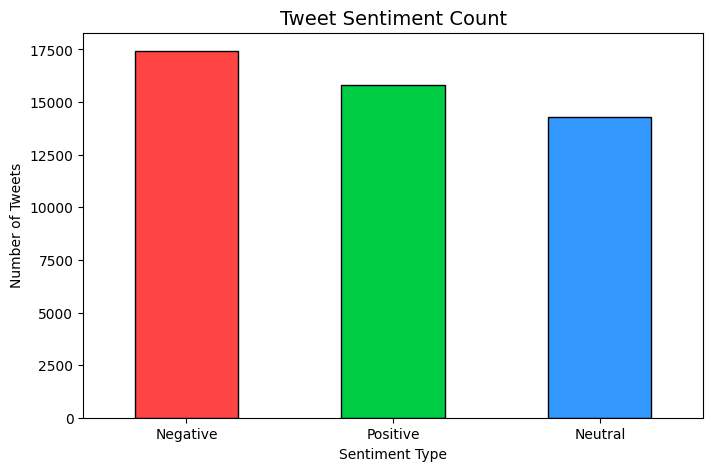

✅ Chart 1 Done!


In [26]:
# CELL 8 — Chart 1: Sentiment Count
plt.figure(figsize=(8,5))
colors = ['#ff4444',
          '#00cc44',
          '#3399ff']
train['sentiment'].value_counts(
    ).plot(
    kind='bar',
    color=colors,
    edgecolor='black')
plt.title(
    'Tweet Sentiment Count',
    fontsize=14)
plt.xlabel('Sentiment Type')
plt.ylabel('Number of Tweets')
plt.xticks(rotation=0)
plt.show()
print("✅ Chart 1 Done!")

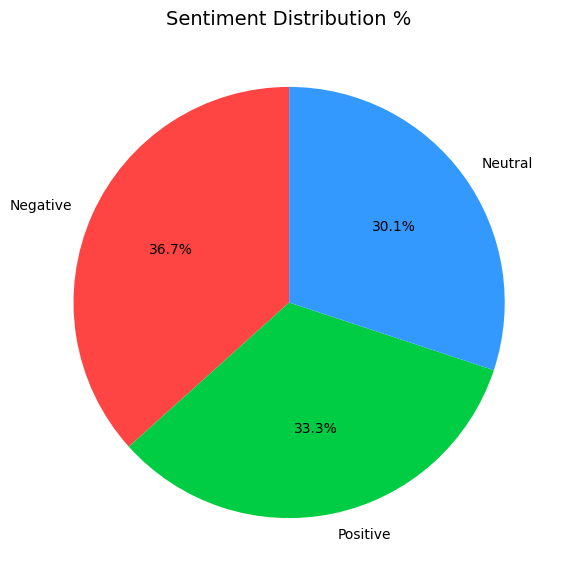

✅ Chart 2 Done!


In [27]:
# CELL 9 — Chart 2: Pie Chart
plt.figure(figsize=(7,7))
colors = ['#ff4444',
          '#00cc44',
          '#3399ff']
train['sentiment'].value_counts(
    ).plot(
    kind='pie',
    colors=colors,
    autopct='%1.1f%%',
    startangle=90)
plt.title(
    'Sentiment Distribution %',
    fontsize=14)
plt.ylabel('')
plt.show()
print("✅ Chart 2 Done!")

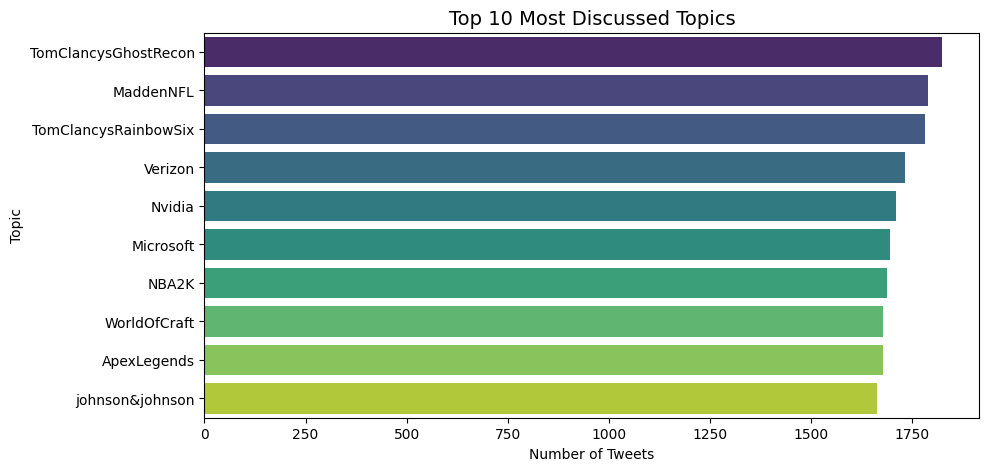

✅ Chart 3 Done!


In [28]:
# CELL 10 — Chart 3: Top Topics
plt.figure(figsize=(10,5))
top_topics = train[
    'topic'].value_counts(
    ).head(10)
sns.barplot(
    x=top_topics.values,
    y=top_topics.index,
    palette='viridis')
plt.title(
    'Top 10 Most Discussed Topics',
    fontsize=14)
plt.xlabel('Number of Tweets')
plt.ylabel('Topic')
plt.show()
print("✅ Chart 3 Done!")

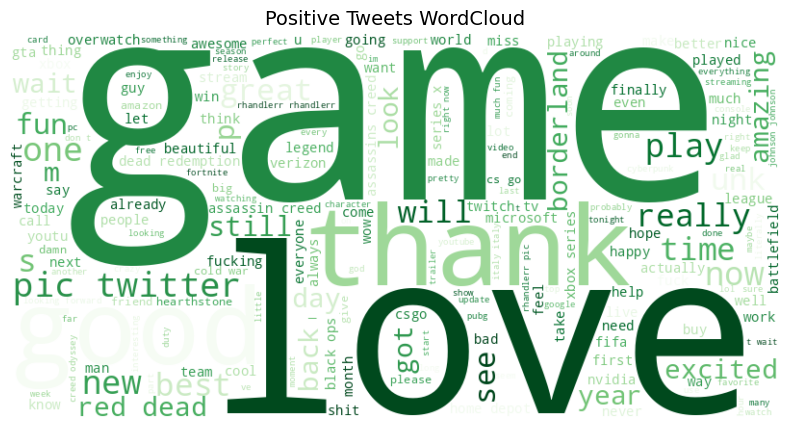

✅ Chart 4 Done!


In [29]:
# CELL 11 — Chart 4: WordCloud
# Install wordcloud first
!pip install wordcloud -q

from wordcloud import WordCloud

# Positive tweets wordcloud
positive = ' '.join(
    train[train['sentiment']
    =='Positive']['clean_tweet'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Greens'
).generate(positive)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud,
    interpolation='bilinear')
plt.title(
    'Positive Tweets WordCloud',
    fontsize=14)
plt.axis('off')
plt.show()
print("✅ Chart 4 Done!")

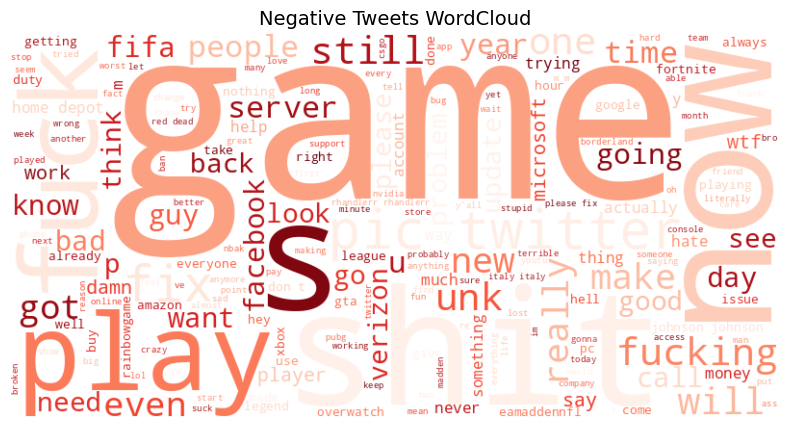

✅ Chart 5 Done!


In [30]:
# CELL 12 — Chart 5: Negative WordCloud
negative = ' '.join(
    train[train['sentiment']
    =='Negative']['clean_tweet'])

wordcloud2 = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Reds'
).generate(negative)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud2,
    interpolation='bilinear')
plt.title(
    'Negative Tweets WordCloud',
    fontsize=14)
plt.axis('off')
plt.show()
print("✅ Chart 5 Done!")

In [31]:
# CELL 13 — Build Sentiment ML Model
from sklearn.model_selection import (
    train_test_split)
from sklearn.feature_extraction.text\
    import TfidfVectorizer
from sklearn.linear_model import (
    LogisticRegression)
from sklearn.metrics import (
    accuracy_score,
    classification_report)

# Convert sentiment to numbers
train['sentiment_num'] = train[
    'sentiment'].map({
    'Positive' : 1,
    'Negative' : 0,
    'Neutral'  : 2})

val['sentiment_num'] = val[
    'sentiment'].map({
    'Positive' : 1,
    'Negative' : 0,
    'Neutral'  : 2})

# Features and Target
X_train = train['clean_tweet']
y_train = train['sentiment_num']
X_test  = val['clean_tweet']
y_test  = val['sentiment_num']

print("✅ Data prepared!")
print("Train size:", len(X_train))
print("Test size :", len(X_test))

# Convert text to numbers
tfidf = TfidfVectorizer(
        max_features=5000)
X_train_tf = tfidf.fit_transform(
             X_train)
X_test_tf  = tfidf.transform(
             X_test)

print("✅ Text converted!")

# Train Model
model = LogisticRegression(
        max_iter=200)
model.fit(X_train_tf, y_train)
print("✅ Model trained!")

# Check Accuracy
y_pred = model.predict(X_test_tf)
accuracy = accuracy_score(
           y_test, y_pred)
print(f"\n✅ Accuracy:"
      f"{accuracy*100:.2f}%")

print("\nDetailed Report:")
print(classification_report(
      y_test, y_pred,
      target_names=[
      'Negative',
      'Positive',
      'Neutral']))

✅ Data prepared!
Train size: 47534
Test size : 12345
✅ Text converted!
✅ Model trained!

✅ Accuracy:76.32%

Detailed Report:
              precision    recall  f1-score   support

    Negative       0.76      0.84      0.80      4519
    Positive       0.77      0.77      0.77      4230
     Neutral       0.75      0.67      0.71      3596

    accuracy                           0.76     12345
   macro avg       0.76      0.76      0.76     12345
weighted avg       0.76      0.76      0.76     12345

